In [1]:
%pip install imbalanced-learn
%pip install shap
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# =========================================================
# CHURNGUARD: CUSTOMER CHURN PREDICTION FRAMEWORK
# =========================================================
# This notebook implements a full machine learning pipeline
# including:
# - Data Cleaning
# - Target-driven EDA
# - Feature Engineering
# - Feature Importance
# - Baseline vs SMOTE vs ADASYN vs Optimised comparison
# - Hyperparameter tuning using GridSearchCV
# - Final evaluation and model selection
# =========================================================


# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model building
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# IMPORTANT: Use imblearn pipeline for resampling integration
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, ADASYN

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)

# Explainability
import shap

import warnings
warnings.filterwarnings("ignore")

In [3]:
#Load the raw telecom churn dataset
df = pd.read_csv("customer_churn.csv")

In [4]:
# Inspect basic structure of the dataset
# This helps us understand size, column names and data types

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 38)


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [5]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

In [7]:
df.columns = (
    df.columns
    .str.strip()  #Removes spaces at the beginning and end
    .str.lower()  #Converts everything to lowercase
    .str.replace(" ", "_") # Removes spaces between words and replaces with an underscore
)

In [8]:
print (df.columns)

Index(['customer_id', 'gender', 'age', 'married', 'number_of_dependents',
       'city', 'zip_code', 'latitude', 'longitude', 'number_of_referrals',
       'tenure_in_months', 'offer', 'phone_service',
       'avg_monthly_long_distance_charges', 'multiple_lines',
       'internet_service', 'internet_type', 'avg_monthly_gb_download',
       'online_security', 'online_backup', 'device_protection_plan',
       'premium_tech_support', 'streaming_tv', 'streaming_movies',
       'streaming_music', 'unlimited_data', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charge', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'customer_status', 'churn_category', 'churn_reason'],
      dtype='object')


In [9]:
# Inspect the target related column to understand class labels
df["customer_status"].value_counts()

customer_status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

In [10]:
# Keep only customers with a definitive churn outcome
# Joined customers are removed because they have no churn history

df = df[df["customer_status"].isin(["Stayed", "Churned"])].copy()

# Create binary target variable
# Stayed  -> 0
# Churned -> 1

df["churn"] = df["customer_status"].map({
    "Stayed": 0,
    "Churned": 1
})


# Verify class balance
df["churn"].value_counts(normalize=True)

churn
0    0.716345
1    0.283655
Name: proportion, dtype: float64

In [11]:
# Drop columns that must not be used for prediction
# This prevents target leakage and proxy leakage

columns_to_drop = [
    "customer_id",
    "customer_status",
    "churn_category",
    "churn_reason",
    "zip_code",
    "latitude",
    "longitude"
]

df = df.drop(columns=columns_to_drop, errors="ignore")

In [12]:
df.isna().sum()[df.isna().sum() > 0]

offer                                3598
avg_monthly_long_distance_charges     644
multiple_lines                        644
internet_type                        1344
avg_monthly_gb_download              1344
online_security                      1344
online_backup                        1344
device_protection_plan               1344
premium_tech_support                 1344
streaming_tv                         1344
streaming_movies                     1344
streaming_music                      1344
unlimited_data                       1344
dtype: int64

In [13]:
# Percentage of missing values for columns with nulls
null_percentage = (df.isna().sum() / len(df)) * 100

# Show only columns that contain missing values
null_percentage[null_percentage > 0]

offer                                54.606162
avg_monthly_long_distance_charges     9.773866
multiple_lines                        9.773866
internet_type                        20.397632
avg_monthly_gb_download              20.397632
online_security                      20.397632
online_backup                        20.397632
device_protection_plan               20.397632
premium_tech_support                 20.397632
streaming_tv                         20.397632
streaming_movies                     20.397632
streaming_music                      20.397632
unlimited_data                       20.397632
dtype: float64

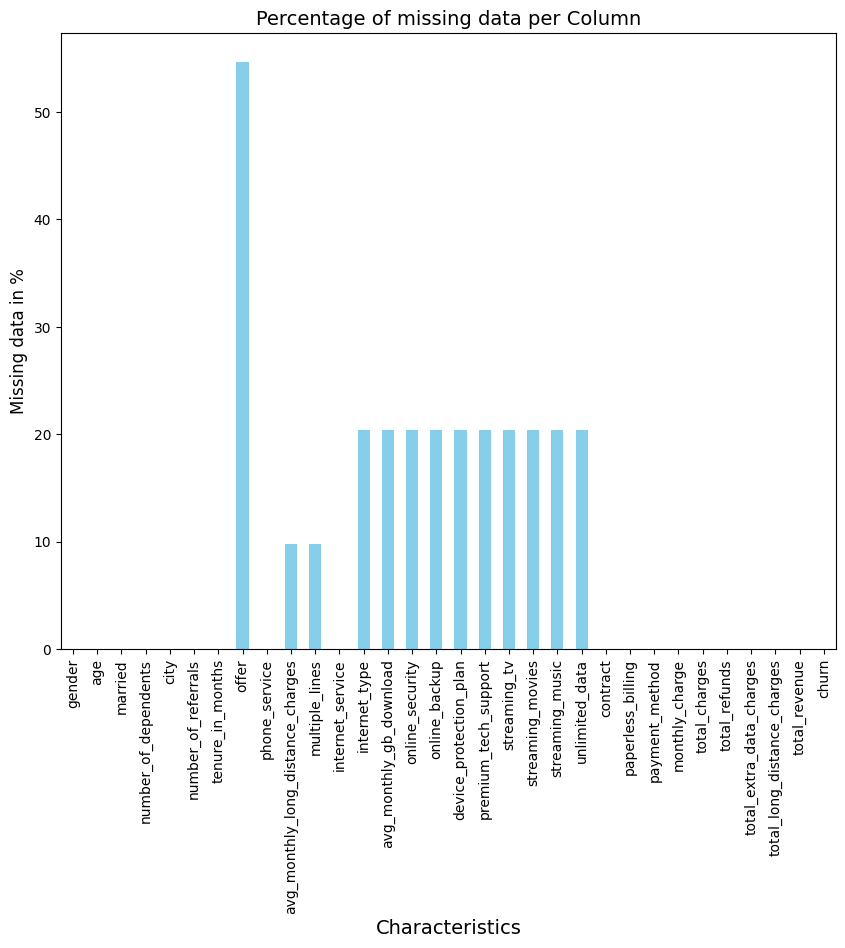

In [14]:
# Plotting the missing data percentages as a bar chart
missing_perc = df.isnull().mean() * 100
plt.figure(figsize=(10, 8))
null_percentage.plot(kind='bar', color='skyblue')
                        
# Adding title and labels
plt.title('Percentage of missing data per Column', fontsize=14)
plt.xlabel('Characteristics', fontsize=14)
plt.ylabel('Missing data in %', fontsize=12)
                        
# Show the plot
plt.show()

In [15]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['gender', 'married', 'city', 'offer', 'phone_service', 'multiple_lines', 'internet_service', 'internet_type', 'online_security', 'online_backup', 'device_protection_plan', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'unlimited_data', 'contract', 'paperless_billing', 'payment_method']
Numerical columns: ['age', 'number_of_dependents', 'number_of_referrals', 'tenure_in_months', 'avg_monthly_long_distance_charges', 'avg_monthly_gb_download', 'monthly_charge', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges', 'total_revenue', 'churn']


In [16]:
# # Specify the numerical columns for outlier detection (excluding income)
# # Set up the plot
# fig, ax = plt.subplots(1, len(num_col), figsize=(29, 12))

# # Create a boxplot for each numerical column
# for i, col in enumerate(num_col):
#     g = sns.boxplot(data=df, y=col, ax=ax[i], color='skyblue')
#     g.set_title(col, weight="bold", fontsize=24, fontname="monospace")

# # Adjust layout to make it look nicer
# plt.tight_layout()
# plt.show()

In [17]:
df.columns

Index(['gender', 'age', 'married', 'number_of_dependents', 'city',
       'number_of_referrals', 'tenure_in_months', 'offer', 'phone_service',
       'avg_monthly_long_distance_charges', 'multiple_lines',
       'internet_service', 'internet_type', 'avg_monthly_gb_download',
       'online_security', 'online_backup', 'device_protection_plan',
       'premium_tech_support', 'streaming_tv', 'streaming_movies',
       'streaming_music', 'unlimited_data', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charge', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'churn'],
      dtype='object')

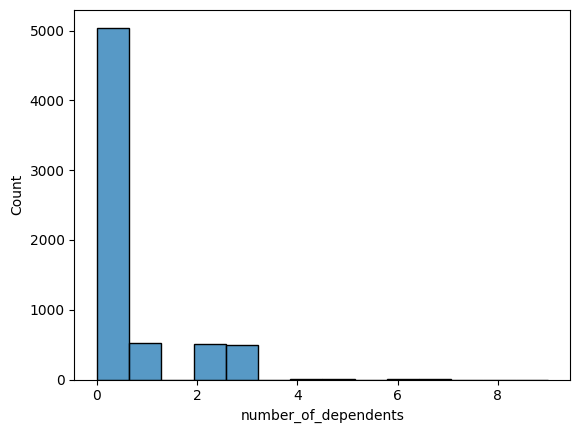

In [18]:
import seaborn as sns
sns.histplot(df['number_of_dependents'])
plt.show()

In [19]:
# Categorical features where missing means no subscription
categorical_missing = [
    "offer",
    "multiple_lines",
    "internet_type",
    "online_security",
    "online_backup",
    "device_protection_plan",
    "premium_tech_support",
    "streaming_tv",
    "streaming_movies",
    "streaming_music",
    "unlimited_data"
]

# Numerical usage features where missing means zero usage
numerical_missing = [
    "avg_monthly_long_distance_charges",
    "avg_monthly_gb_download"
]

# Fill categorical missing values
df[categorical_missing] = df[categorical_missing].fillna("No")

# Fill numerical missing values
df[numerical_missing] = df[numerical_missing].fillna(0)

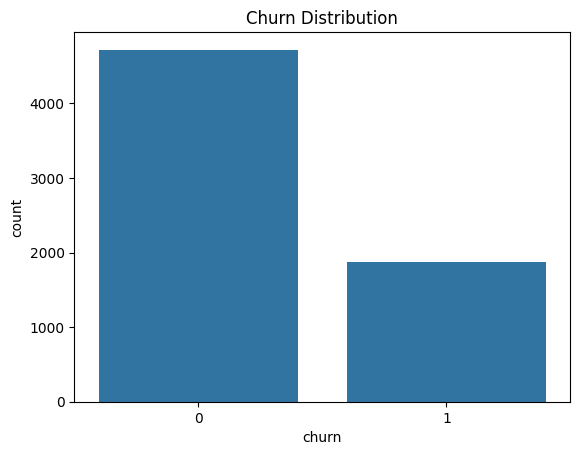

In [20]:
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

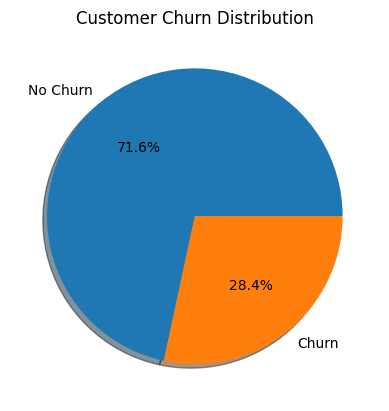

In [21]:
plt.pie(
    df["churn"].value_counts(),
    labels=["No Churn", "Churn"],
    autopct="%.1f%%",
    shadow=True
)

plt.title("Customer Churn Distribution")
# This was done to check for data imbalance

plt.show()

In [22]:
# =========================================================
# 5. FEATURE ENGINEERING
# =========================================================

# --- Age binning (captures behavioural patterns across age groups)
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ["0-20", "21-30", "31-40", "41-50", "51-60", "60+"]

df["AgeGroup"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    right=False
)

# --- Tenure grouping (important churn indicator)
df['Tenure'] = pd.cut(
    df['tenure_in_months'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4+yr']
)

# --- Interaction feature (captures cost intensity)
df['Charge_per_Tenure'] = df['monthly_charge'] / (df['tenure_in_months'] + 1)
df["AvgRevenuePerMonth"] = df["total_revenue"] / (df["tenure_in_months"] + 1)

In [23]:
df.columns

Index(['gender', 'age', 'married', 'number_of_dependents', 'city',
       'number_of_referrals', 'tenure_in_months', 'offer', 'phone_service',
       'avg_monthly_long_distance_charges', 'multiple_lines',
       'internet_service', 'internet_type', 'avg_monthly_gb_download',
       'online_security', 'online_backup', 'device_protection_plan',
       'premium_tech_support', 'streaming_tv', 'streaming_movies',
       'streaming_music', 'unlimited_data', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charge', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'churn', 'AgeGroup', 'Tenure', 'Charge_per_Tenure',
       'AvgRevenuePerMonth'],
      dtype='object')

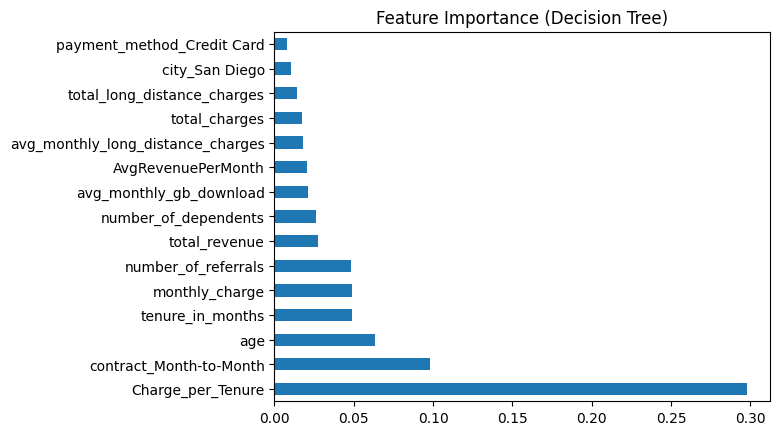

In [24]:
# =========================================================
# 6. FEATURE IMPORTANCE (BEFORE DROPPING ANY FEATURES)
# =========================================================

# Convert categorical variables to numeric for tree model
X_temp = pd.get_dummies(df.drop('churn', axis=1))
y_temp = df['churn']

# Train Decision Tree to extract feature importance
dt = DecisionTreeClassifier()
dt.fit(X_temp, y_temp)

# Plot top features
importance = pd.Series(dt.feature_importances_, index=X_temp.columns)
importance.nlargest(15).plot(kind='barh')
plt.title("Feature Importance (Decision Tree)")
plt.show()

In [25]:
#df['churn_binary'] = df['churn'].map({'Yes': 1, 'No': 0})

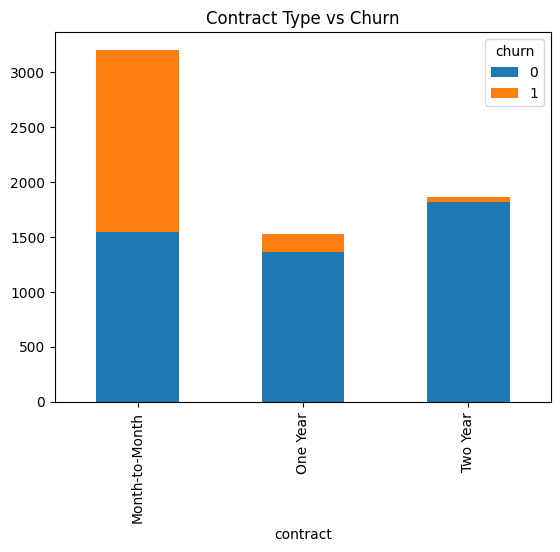

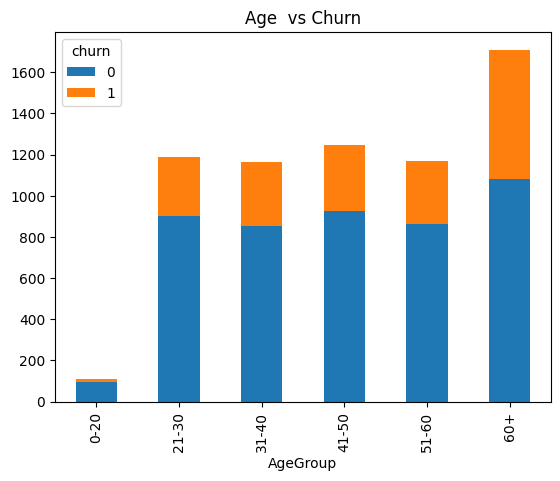

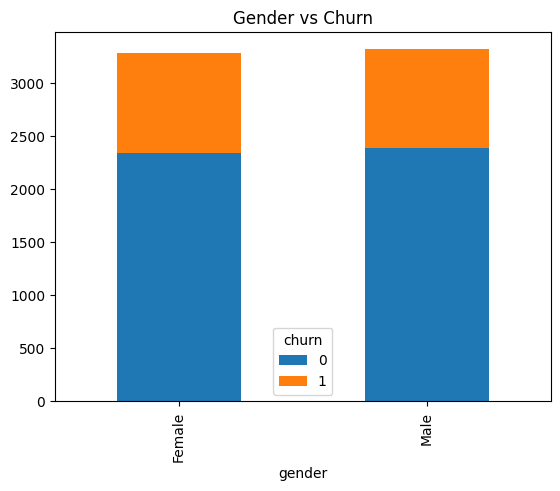

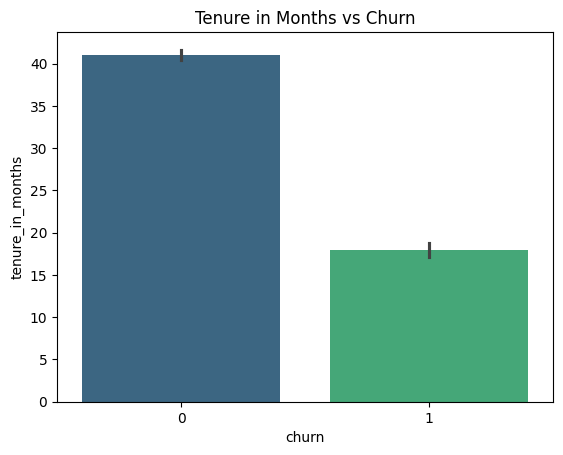

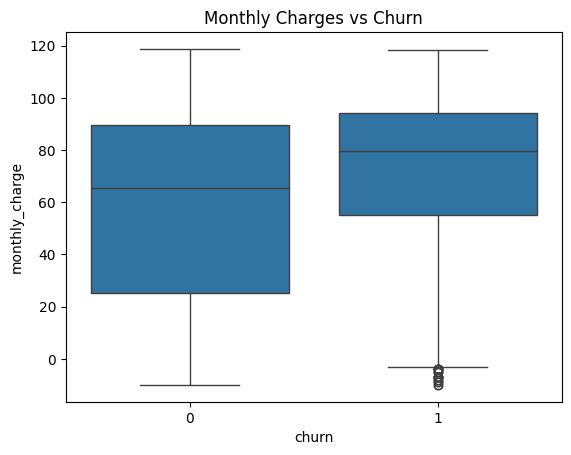

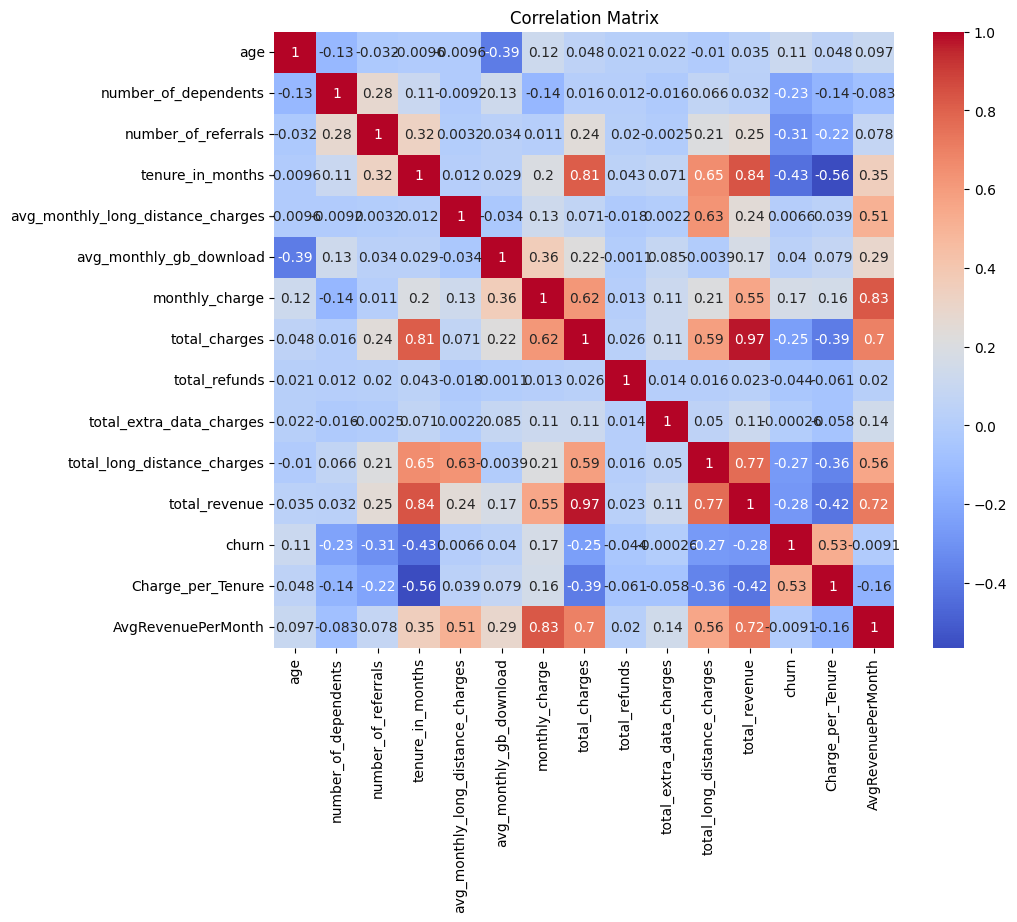

In [26]:
# =========================================================
# 4. TARGET-DRIVEN EXPLORATORY DATA ANALYSIS (EDA)
# =========================================================

# --- Contract Type vs Churn
pd.crosstab(df['contract'], df['churn']).plot(kind='bar', stacked=True)
plt.title("Contract Type vs Churn")
plt.show()

pd.crosstab(df['AgeGroup'], df['churn']).plot(kind='bar', stacked=True)
plt.title("Age  vs Churn")
plt.show()

pd.crosstab(df['gender'], df['churn']).plot(kind='bar', stacked=True)
plt.title("Gender vs Churn")
plt.show()

sns.barplot(x="churn", y="tenure_in_months", data=df, palette="viridis")
plt.title("Tenure in Months vs Churn")
plt.show()


# --- Monthly Charges vs Churn
sns.boxplot(x='churn', y='monthly_charge', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

# --- Correlation Heatmap (numerical relationships)
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [27]:
# Less important features were dropped after doing feature importance
columns_to_drop = [
    "age",
    "married",
    "number_of_dependents",
    "tenure_in_months",
    "offer",
    "phone_service",
    "multiple_lines",
    "internet_type",
    "online_security",
    "online_backup",
    "device_protection_plan",
    "premium_tech_support",
    "streaming_tv", 
    "streaming_movies",
    "streaming_music", 
    "unlimited_data",
    "paperless_billing",
    "payment_method",
    "total_revenue",
    "monthly_charge",
    "total_refunds",
    "gender",
]

df = df.drop(columns=columns_to_drop, errors="ignore")

In [28]:
df.columns

Index(['city', 'number_of_referrals', 'avg_monthly_long_distance_charges',
       'internet_service', 'avg_monthly_gb_download', 'contract',
       'total_charges', 'total_extra_data_charges',
       'total_long_distance_charges', 'churn', 'AgeGroup', 'Tenure',
       'Charge_per_Tenure', 'AvgRevenuePerMonth'],
      dtype='object')

In [29]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['city', 'internet_service', 'contract']
Numerical columns: ['number_of_referrals', 'avg_monthly_long_distance_charges', 'avg_monthly_gb_download', 'total_charges', 'total_extra_data_charges', 'total_long_distance_charges', 'churn', 'AgeGroup', 'Tenure', 'Charge_per_Tenure', 'AvgRevenuePerMonth']


In [30]:
# =========================================================
# 7. PREPARE DATA FOR MODELLING
# =========================================================

X = df.drop('churn', axis=1)
y = df['churn']

# 'categorical' now includes strings (object) AND pandas categories
categorical = X.select_dtypes(include=['object', 'category']).columns

# 'numerical' now ONLY includes actual numbers (int, float)
numerical = X.select_dtypes(include=['number']).columns

In [31]:
# ========================================================= nikita put it here because it should be before i split the model :)
# 9. PREPROCESSING PIPELINE
# =========================================================

# Standardise numerical features and encode categorical features
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])

In [32]:
# =========================================================
# 8. TRAIN-TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        # preserves class distribution
    random_state=42
)

In [42]:
from sklearn.model_selection import GridSearchCV
# =========================================================
# 10. DEFINE MODELS
# =========================================================
# Keep this for better compatibility with C penalties  Nikki tells me to try with different numbers iterating thru numbers to narrow down to the right number , and explain in report!!!!!!!!!!!!!!!
# find a way to print the best number and optimize it

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

# =========================
# PARAM GRIDS
# =========================
param_grids = {
    "Logistic Regression": {
        'model__C': np.linspace(0.1, 0.3, 10),
        'model__solver': ['liblinear']
    },
    
    "Decision Tree": {
        'model__max_depth': [4, 5, 6, 7],
        'model__min_samples_split': [8, 10, 12]
    },
    
    "Random Forest": {
        'model__n_estimators': [150, 200, 250],
        'model__max_depth': [None, 20, 30],
        'model__min_samples_split': [2, 3, 4]
    },
    
    "XGBoost": {
        'model__learning_rate': [0.08, 0.1, 0.12],
        'model__n_estimators': [150, 200, 250],
        'model__max_depth': [2, 3, 4]
    }
}

# =========================
# OPTIMISATION LOOP
# =========================
best_models = {}
results_summary = []

for name, model in models.items():
    
    print(f"\n===== Tuning {name} =====")
    
    # Create pipeline ONCE per model
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    grid = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    best_models[name] = grid.best_estimator_
    
    results_summary.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Best CV Score": grid.best_score_
    })
    
    print("Best Parameters:", grid.best_params_)
    print("Best CV Score:", round(grid.best_score_, 4))


# =========================
# FINAL TEST PERFORMANCE
# =========================
print("\n===== Final Model Performance =====")

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"{name}: {round(acc, 4)}")



===== Tuning Logistic Regression =====
Best Parameters: {'model__C': np.float64(0.1), 'model__solver': 'liblinear'}
Best CV Score: 0.8497

===== Tuning Decision Tree =====
Best Parameters: {'model__max_depth': 7, 'model__min_samples_split': 8}
Best CV Score: 0.8486

===== Tuning Random Forest =====
Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 4, 'model__n_estimators': 200}
Best CV Score: 0.8634

===== Tuning XGBoost =====
Best Parameters: {'model__learning_rate': 0.12, 'model__max_depth': 2, 'model__n_estimators': 150}
Best CV Score: 0.8716

===== Final Model Performance =====
Logistic Regression: 0.8392
Decision Tree: 0.8323
Random Forest: 0.8437
XGBoost: 0.8452


In [43]:
from sklearn.base import clone

# =========================================================
# 12. EXPERIMENT: BASELINE vs SMOTE vs ADASYN vs OPTIMISED
# =========================================================

# =========================================================
# 12. EXPERIMENT: BASELINE vs SMOTE vs ADASYN vs OPTIMISED
# =========================================================

results = []
best_models = {}

for model_name, model in models.items():
    
    print(f"\n========== {model_name} ==========")
    
    # -------------------------
    # 1. BASELINE MODEL
    # -------------------------
    pipeline_base = Pipeline([
        ('preprocessor', preprocessor),
        ('model', clone(model))
    ])
    
    pipeline_base.fit(X_train, y_train)
    y_pred_base = pipeline_base.predict(X_test)
    
    f1_base = f1_score(y_test, y_pred_base)
    acc_base = accuracy_score(y_test, y_pred_base)
    
    results.append({
        "Model": model_name,
        "Type": "Baseline",
        "Accuracy": acc_base,
        "F1": f1_base,
        "Recall": recall_score(y_test, y_pred_base),
        "Precision": precision_score(y_test, y_pred_base)
    })
    
    
    # -------------------------
    # 2. SMOTE MODEL
    # -------------------------
    pipeline_smote = Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', clone(model))
    ])
    
    pipeline_smote.fit(X_train, y_train)
    y_pred_smote = pipeline_smote.predict(X_test)
    
    f1_smote = f1_score(y_test, y_pred_smote)
    acc_smote = accuracy_score(y_test, y_pred_smote)
    
    results.append({
        "Model": model_name,
        "Type": "SMOTE",
        "Accuracy": acc_smote,
        "F1": f1_smote,
        "Recall": recall_score(y_test, y_pred_smote),
        "Precision": precision_score(y_test, y_pred_smote)
    })
    
    
    # -------------------------
    # 3. ADASYN MODEL
    # -------------------------
    pipeline_adasyn = Pipeline([
        ('preprocessor', preprocessor),
        ('adasyn', ADASYN(random_state=42)),
        ('model', clone(model))
    ])
    
    pipeline_adasyn.fit(X_train, y_train)
    y_pred_adasyn = pipeline_adasyn.predict(X_test)
    
    f1_adasyn = f1_score(y_test, y_pred_adasyn)
    acc_adasyn = accuracy_score(y_test, y_pred_adasyn)
    
    results.append({
        "Model": model_name,
        "Type": "ADASYN",
        "Accuracy": acc_adasyn,
        "F1": f1_adasyn,
        "Recall": recall_score(y_test, y_pred_adasyn),
        "Precision": precision_score(y_test, y_pred_adasyn)
    })
    
    
    # -------------------------
    # 4. SELECT BEST RESAMPLING (based on F1)
    # -------------------------
    if f1_smote >= f1_adasyn:
        best_resampler = SMOTE(random_state=42)
        best_type = "SMOTE"
    else:
        best_resampler = ADASYN(random_state=42)
        best_type = "ADASYN"
    
    
    # -------------------------
    # 5. OPTIMISED MODEL (GRIDSEARCH)
    # -------------------------
    if model_name in param_grids:
        
        pipeline_opt = Pipeline([
            ('preprocessor', preprocessor),
            ('resample', best_resampler),
            ('model', clone(model))
        ])
        
        grid = GridSearchCV(
            pipeline_opt,
            param_grids[model_name],
            cv=5, # Use 5-fold CV for more reliable estimates
            scoring='f1',
            n_jobs=-1
        )
        
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        
        y_pred_opt = best_model.predict(X_test)
        
        results.append({
            "Model": model_name,
            "Type": f"Optimised ({best_type})",
            "Accuracy": accuracy_score(y_test, y_pred_opt),
            "F1": f1_score(y_test, y_pred_opt),
            "Recall": recall_score(y_test, y_pred_opt),
            "Precision": precision_score(y_test, y_pred_opt)
        })
        
        best_models[model_name] = best_model


        ########## Here put cross validation  and u will talk about it ina  paragraph in the report and it will be beautiful !!


========== Logistic Regression ==========

========== Decision Tree ==========

========== Random Forest ==========

========== XGBoost ==========


In [44]:
results

[{'Model': 'Logistic Regression',
  'Type': 'Baseline',
  'Accuracy': 0.8254931714719271,
  'F1': 0.6607669616519174,
  'Recall': 0.5989304812834224,
  'Precision': 0.7368421052631579},
 {'Model': 'Logistic Regression',
  'Type': 'SMOTE',
  'Accuracy': 0.8133535660091047,
  'F1': 0.7036144578313253,
  'Recall': 0.7807486631016043,
  'Precision': 0.6403508771929824},
 {'Model': 'Logistic Regression',
  'Type': 'ADASYN',
  'Accuracy': 0.7905918057663126,
  'F1': 0.6877828054298643,
  'Recall': 0.8128342245989305,
  'Precision': 0.596078431372549},
 {'Model': 'Logistic Regression',
  'Type': 'Optimised (SMOTE)',
  'Accuracy': 0.8072837632776935,
  'F1': 0.7011764705882353,
  'Recall': 0.7967914438502673,
  'Precision': 0.6260504201680672},
 {'Model': 'Decision Tree',
  'Type': 'Baseline',
  'Accuracy': 0.7974203338391502,
  'F1': 0.6317241379310344,
  'Recall': 0.6122994652406417,
  'Precision': 0.6524216524216524},
 {'Model': 'Decision Tree',
  'Type': 'SMOTE',
  'Accuracy': 0.8095599393

                  Model                Type  Accuracy        F1    Recall  \
15              XGBoost   Optimised (SMOTE)  0.849014  0.738502  0.751337   
11        Random Forest  Optimised (ADASYN)  0.845979  0.734641  0.751337   
7         Decision Tree  Optimised (ADASYN)  0.821700  0.726426  0.834225   
13              XGBoost               SMOTE  0.846737  0.723288  0.705882   
10        Random Forest              ADASYN  0.839150  0.716578  0.716578   
12              XGBoost            Baseline  0.844461  0.711674  0.676471   
14              XGBoost              ADASYN  0.833080  0.710526  0.721925   
9         Random Forest               SMOTE  0.839150  0.708791  0.689840   
1   Logistic Regression               SMOTE  0.813354  0.703614  0.780749   
8         Random Forest            Baseline  0.851290  0.701220  0.614973   
3   Logistic Regression   Optimised (SMOTE)  0.807284  0.701176  0.796791   
2   Logistic Regression              ADASYN  0.790592  0.687783  0.812834   

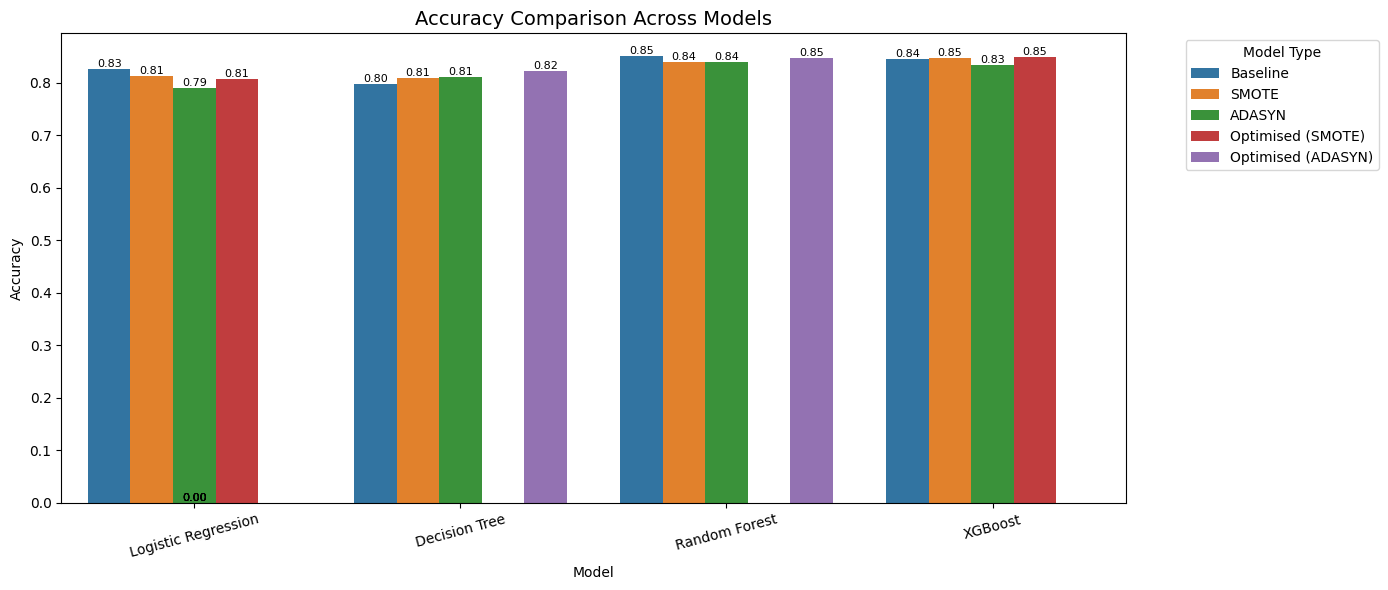

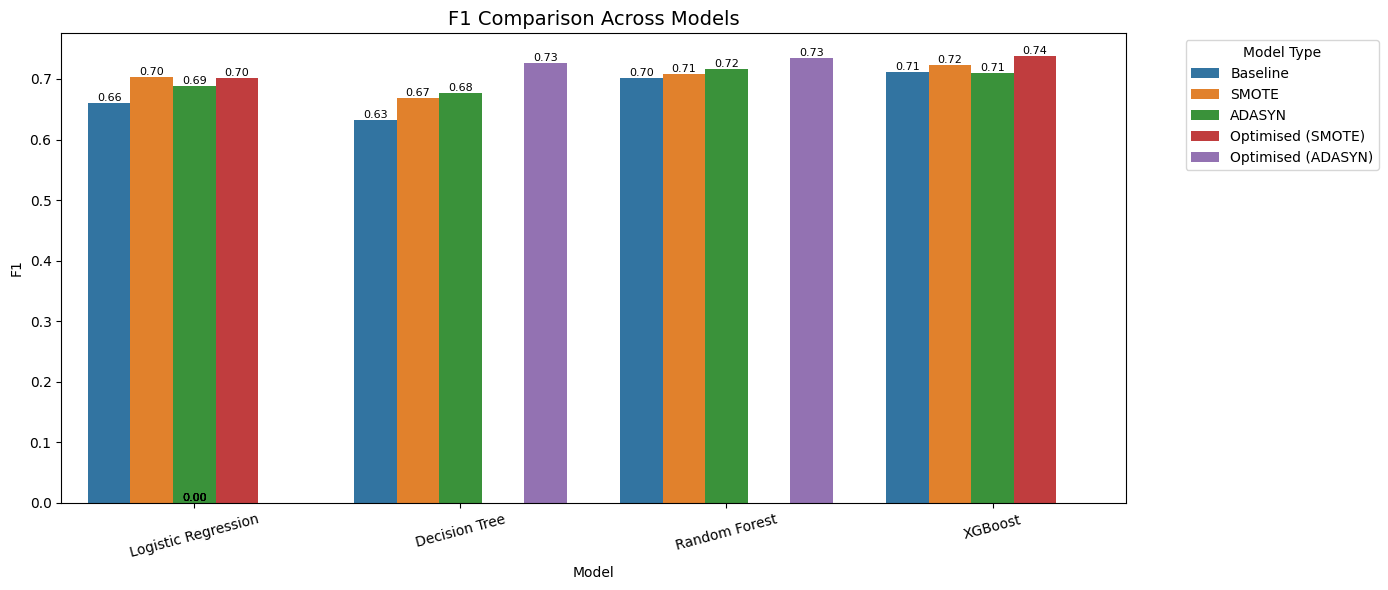

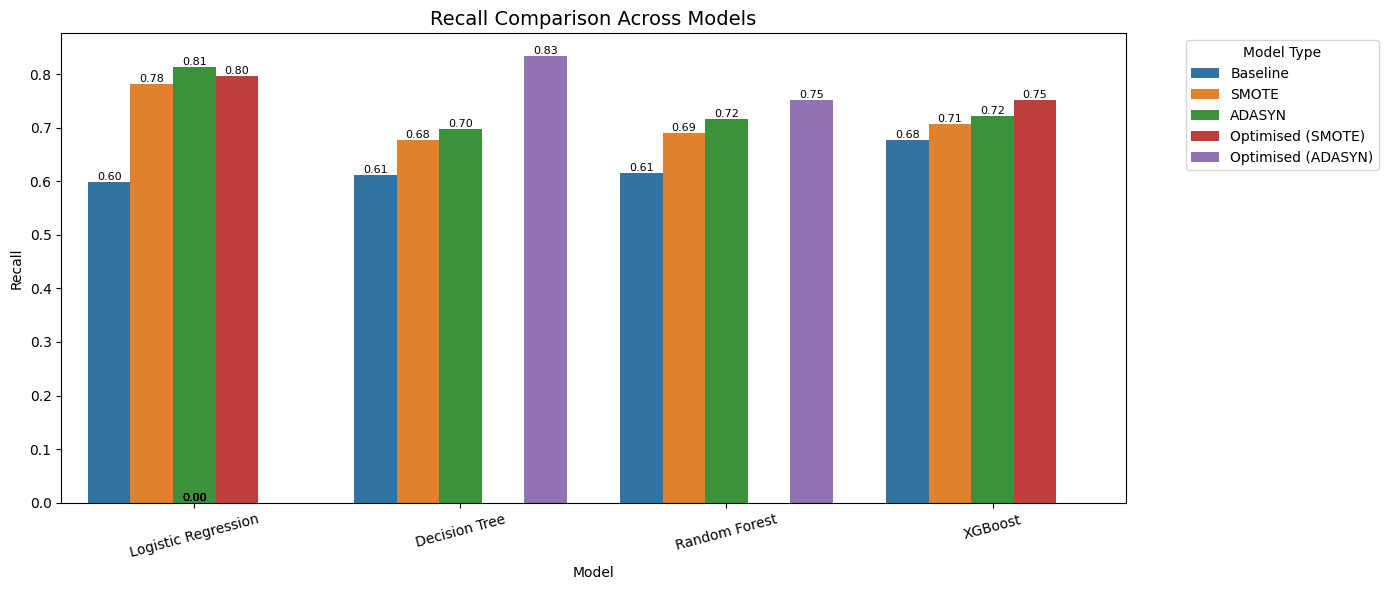

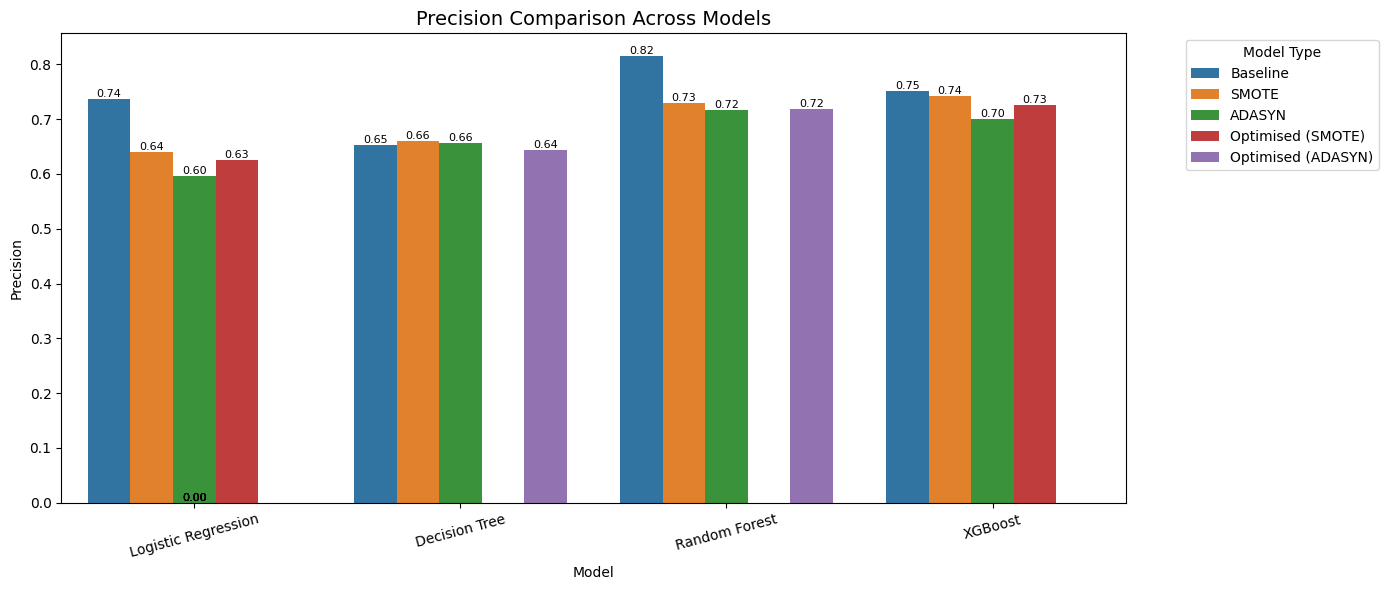


Best Model:
Model                  XGBoost
Type         Optimised (SMOTE)
Accuracy              0.849014
F1                    0.738502
Recall                0.751337
Precision             0.726098
Name: 15, dtype: object


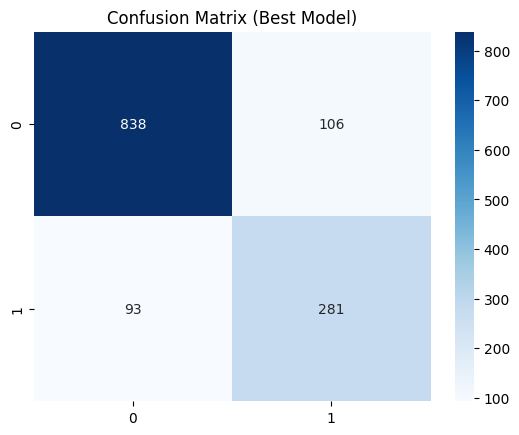

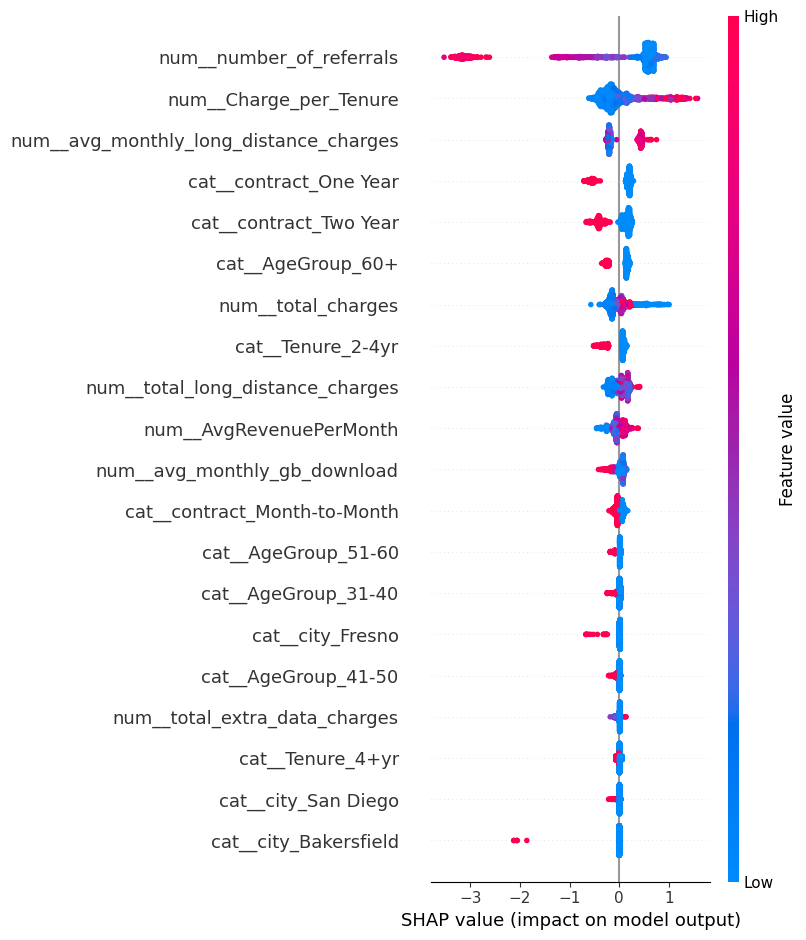

In [56]:
# =========================================================
# 13. RESULTS ANALYSIS
# =========================================================

results_df = pd.DataFrame(results)
print(results_df.sort_values(by="F1", ascending=False))


# =========================================================
# 14. VISUAL COMPARISON
# =========================================================

metrics = ["Accuracy", "F1", "Recall", "Precision"]

for metric in metrics:
    plt.figure(figsize=(14,6))
    
    ax = sns.barplot(
        data=results_df,
        x="Model",
        y=metric,
        hue="Type"
    )
    
    plt.title(f"{metric} Comparison Across Models", fontsize=14)
    plt.xlabel("Model")
    plt.ylabel(metric)
    
    plt.xticks(rotation=15)
    plt.legend(title="Model Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add value labels
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()


# =========================================================
# 15. BEST MODEL EVALUATION
# =========================================================

best_row = results_df.sort_values(by="F1", ascending=False).iloc[0]
print("\nBest Model:")
print(best_row)

best_model = best_models[best_row['Model']]

y_pred = best_model.predict(X_test)

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Best Model)")
plt.show()


############################################### print accuracy. then, focus on recall, precision, accuracy and (f1 score!!!!!!!!!!!!) and then a confusion matrix. 

# =========================================================
# 16. SHAP EXPLAINABILITY
# =========================================================

# Transform data
X_transformed = best_model.named_steps['preprocessor'].transform(X_test)

# Convert to dense if needed
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

# Get trained model
model = best_model.named_steps['model']

# Create explainer
explainer = shap.Explainer(model, X_transformed)

# Compute SHAP values
shap_values = explainer(X_transformed)

# Get feature names (safe)
if hasattr(best_model.named_steps['preprocessor'], "get_feature_names_out"):
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
else:
    feature_names = None

# Plot
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)


